# 05. 추천 시스템 설계 인사이트

EDA 결과를 MindTune 추천 시스템 설계와 연결하는 종합 분석입니다.

**핵심 검증 항목**:
1. 기획안의 감정-피처 매핑 가이드가 실제 데이터와 부합하는가?
2. 상황 프리셋 조건에 매칭되는 곡이 충분한가?
3. 코사인 유사도 기반 유사곡 검색이 의미 있는 결과를 내는가?
4. 동질 원리(Iso Principle) 플레이리스트에 충분한 곡이 있는가?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('../data/Music_recommendation.csv')

FEATURE_COLS = ['danceability', 'energy', 'valence', 'acousticness', 
                'instrumentalness', 'speechiness', 'loudness', 'liveness']

# 피처 정규화 (코사인 유사도용)
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])

print(f"데이터셋: {len(df):,}곡")

데이터셋: 32,833곡


## 5.1 감정-피처 매핑 검증

기획안 Section 6.1의 감정별 피처 범위 가이드가 실제 데이터에서 얼마나 많은 곡과 매칭되는지 확인합니다.

=== 감정별 피처 범위에 매칭되는 곡 수 ===
             Emotion  Matching Tracks Percentage
Very Happy / Excited             2593       7.9%
   Happy / Feel Good             1484       4.5%
      Calm / Relaxed              571       1.7%
       Empty / Blank              487       1.5%
     Sad / Depressed              872       2.7%
   Anxious / Nervous             1019       3.1%
  Angry / Frustrated             1979       6.0%


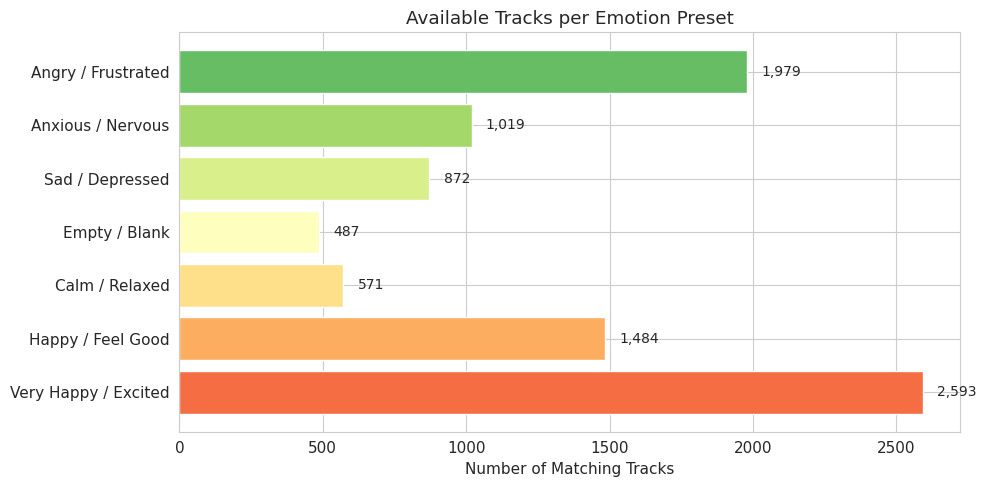


=== 주의: 매칭 곡 100개 미만인 감정 ===


In [2]:
# 기획안의 감정-피처 가이드 (Section 6.1)
emotion_presets = {
    'Very Happy / Excited':   {'valence': (0.7, 1.0), 'energy': (0.7, 1.0), 'tempo': (120, 300)},
    'Happy / Feel Good':      {'valence': (0.5, 0.8), 'energy': (0.5, 0.7), 'tempo': (100, 130)},
    'Calm / Relaxed':         {'valence': (0.4, 0.6), 'energy': (0.2, 0.5), 'acousticness': (0.4, 1.0)},
    'Empty / Blank':          {'valence': (0.2, 0.4), 'energy': (0.2, 0.4), 'acousticness': (0.3, 1.0)},
    'Sad / Depressed':        {'valence': (0.0, 0.3), 'energy': (0.2, 0.5), 'acousticness': (0.3, 1.0)},
    'Anxious / Nervous':      {'valence': (0.2, 0.4), 'energy': (0.3, 0.6), 'acousticness': (0.3, 1.0)},
    'Angry / Frustrated':     {'valence': (0.1, 0.3), 'energy': (0.5, 0.8), 'tempo': (90, 140)},
}

results = []
for emotion, conditions in emotion_presets.items():
    mask = pd.Series(True, index=df.index)
    for feat, (lo, hi) in conditions.items():
        mask &= df[feat].between(lo, hi)
    count = mask.sum()
    results.append({'Emotion': emotion, 'Matching Tracks': count, 
                    'Percentage': f'{count/len(df)*100:.1f}%'})

emotion_results = pd.DataFrame(results)
print("=== 감정별 피처 범위에 매칭되는 곡 수 ===")
print(emotion_results.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(emotion_results['Emotion'], emotion_results['Matching Tracks'], 
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(emotion_results))), edgecolor='white')
ax.set_xlabel('Number of Matching Tracks')
ax.set_title('Available Tracks per Emotion Preset')
for bar, val in zip(bars, emotion_results['Matching Tracks']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 경고: 매칭 곡이 너무 적은 감정
print("\n=== 주의: 매칭 곡 100개 미만인 감정 ===")
for _, row in emotion_results[emotion_results['Matching Tracks'] < 100].iterrows():
    print(f"  ⚠️ {row['Emotion']}: {row['Matching Tracks']}곡 → 추천 다양성 부족 우려")

## 5.2 상황 프리셋 검증

기획안 Section 6.2의 상황별 피처 조건에 매칭되는 곡 수를 확인합니다.

=== 상황별 피처 조건에 매칭되는 곡 수 ===
         Situation  Matching Tracks Percentage
    Cafe + Reading               49      0.15%
       House Party             4018     12.24%
 Late Night Coding              148      0.45%
 Workout / Running             1964      5.98%
    Rainy Day Mood              147      0.45%
           Driving             8097     24.66%
Sleep / Relaxation                1      0.00%


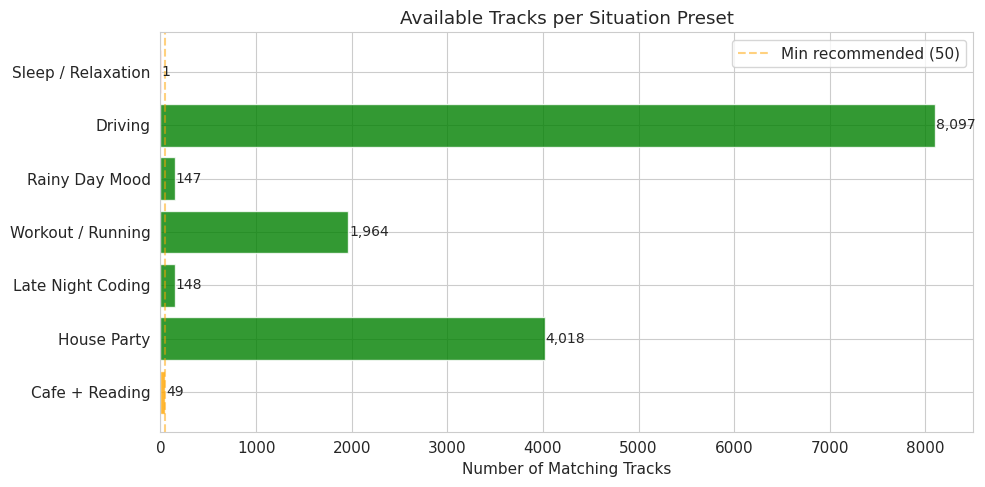

In [3]:
situation_presets = {
    'Cafe + Reading':    {'danceability': (0.0, 0.6), 'energy': (0.2, 0.5), 'acousticness': (0.5, 1.0), 
                          'instrumentalness': (0.2, 1.0), 'speechiness': (0.0, 0.1), 'tempo': (70, 110)},
    'House Party':       {'danceability': (0.7, 1.0), 'energy': (0.5, 0.8), 'tempo': (100, 130)},
    'Late Night Coding': {'energy': (0.3, 0.6), 'instrumentalness': (0.4, 1.0), 
                          'speechiness': (0.0, 0.05), 'tempo': (80, 120)},
    'Workout / Running': {'danceability': (0.7, 1.0), 'energy': (0.8, 1.0), 'tempo': (120, 300)},
    'Rainy Day Mood':    {'danceability': (0.0, 0.5), 'energy': (0.2, 0.5), 'acousticness': (0.5, 1.0),
                          'speechiness': (0.0, 0.1), 'tempo': (60, 100)},
    'Driving':           {'danceability': (0.6, 1.0), 'energy': (0.6, 0.9), 'tempo': (100, 140)},
    'Sleep / Relaxation':{'danceability': (0.0, 0.4), 'energy': (0.0, 0.3), 'acousticness': (0.6, 1.0),
                          'instrumentalness': (0.5, 1.0), 'speechiness': (0.0, 0.05), 'tempo': (0, 80)},
}

results = []
for situation, conditions in situation_presets.items():
    mask = pd.Series(True, index=df.index)
    for feat, (lo, hi) in conditions.items():
        mask &= df[feat].between(lo, hi)
    count = mask.sum()
    results.append({'Situation': situation, 'Matching Tracks': count,
                    'Percentage': f'{count/len(df)*100:.2f}%'})

situation_results = pd.DataFrame(results)
print("=== 상황별 피처 조건에 매칭되는 곡 수 ===")
print(situation_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if r['Matching Tracks'] >= 50 else ('orange' if r['Matching Tracks'] >= 10 else 'red') 
          for _, r in situation_results.iterrows()]
bars = ax.barh(situation_results['Situation'], situation_results['Matching Tracks'], 
               color=colors, edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Matching Tracks')
ax.set_title('Available Tracks per Situation Preset')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, label='Min recommended (50)')
ax.legend()
for bar, val in zip(bars, situation_results['Matching Tracks']):
    ax.text(max(val + 10, 15), bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5.3 유사곡 검색 시뮬레이션

임의의 곡을 선정하고, 코사인 유사도 기반으로 Top-5 유사곡을 찾아봅니다.

In [4]:
def find_similar_tracks(df, df_scaled, track_name, feature_cols, top_k=5):
    """코사인 유사도 기반 유사곡 검색"""
    matches = df[df['track_name'].str.contains(track_name, case=False, na=False)]
    if matches.empty:
        print(f"'{track_name}'을(를) 찾을 수 없습니다.")
        return None
    
    idx = matches.index[0]
    query_vec = df_scaled.loc[idx, feature_cols].values.reshape(1, -1)
    all_vecs = df_scaled[feature_cols].values
    
    sims = cosine_similarity(query_vec, all_vecs).flatten()
    # 자기 자신 제외
    sims[idx] = -1
    top_indices = sims.argsort()[-top_k:][::-1]
    
    ref = df.loc[idx]
    print(f"=== Reference: {ref['track_name']} — {ref['track_artist']} ===")
    print(f"    Genre: {ref['playlist_genre']} | Energy: {ref['energy']:.2f} | "
          f"Valence: {ref['valence']:.2f} | Tempo: {ref['tempo']:.0f}")
    print(f"\n  Top-{top_k} Similar Tracks:")
    
    results = []
    for rank, i in enumerate(top_indices, 1):
        row = df.loc[i]
        sim = sims[i]
        print(f"  {rank}. {row['track_name']} — {row['track_artist']} "
              f"(sim={sim:.4f}, genre={row['playlist_genre']}, "
              f"E={row['energy']:.2f}, V={row['valence']:.2f})")
        results.append(row)
    return results

# 인기 곡으로 테스트
test_songs = ['Yellow', 'Blinding Lights', 'Stay With Me']
for song in test_songs:
    find_similar_tracks(df, df_scaled, song, FEATURE_COLS)
    print()

=== Reference: Bodak Yellow — Cardi B ===
    Genre: r&b | Energy: 0.70 | Valence: 0.48 | Tempo: 125

  Top-5 Similar Tracks:
  1. Nobody Else — Wahlstedt (sim=0.9987, genre=edm, E=0.66, V=0.46)
  2. Nobody Else — Wahlstedt (sim=0.9987, genre=pop, E=0.66, V=0.46)
  3. Paradise — Rex Orange County (sim=0.9987, genre=pop, E=0.53, V=0.36)
  4. The Formula — The D.O.C. (sim=0.9984, genre=rap, E=0.63, V=0.47)
  5. Noche Loca Remix — Oken (sim=0.9983, genre=latin, E=0.64, V=0.48)

=== Reference: Blinding Lights — The Weeknd ===
    Genre: latin | Energy: 0.80 | Valence: 0.34 | Tempo: 171

  Top-5 Similar Tracks:
  1. Blinding Lights — The Weeknd (sim=1.0000, genre=latin, E=0.80, V=0.34)
  2. Blinding Lights — The Weeknd (sim=1.0000, genre=pop, E=0.80, V=0.34)
  3. Blinding Lights — The Weeknd (sim=1.0000, genre=edm, E=0.80, V=0.34)
  4. Blinding Lights — The Weeknd (sim=1.0000, genre=pop, E=0.80, V=0.34)
  5. Blinding Lights — The Weeknd (sim=1.0000, genre=r&b, E=0.80, V=0.34)

=== Reference

## 5.4 동질 원리(Iso Principle) 시뮬레이션

특정 감정(예: 우울, valence=0.2)에서 목표 감정(편안, valence=0.5)으로의 경로에 충분한 곡이 존재하는지 확인합니다.

▶ Scenario 1: Depression → Calm

=== Iso Principle: valence 0.15 → 0.50 (5 steps) ===
    Tolerance: ±0.05
  Step 1: target_v=0.150 → 2,625곡 available (6 genres)
  Step 2: target_v=0.237 → 3,395곡 available (6 genres)
  Step 3: target_v=0.325 → 4,158곡 available (6 genres)
  Step 4: target_v=0.412 → 4,440곡 available (6 genres)
  Step 5: target_v=0.500 → 4,712곡 available (6 genres)


▶ Scenario 2: Anxious → Peaceful

=== Iso Principle: valence 0.25 → 0.60 (5 steps) ===
    Tolerance: ±0.05
  Step 1: target_v=0.250 → 3,503곡 available (6 genres)
  Step 2: target_v=0.338 → 4,235곡 available (6 genres)
  Step 3: target_v=0.425 → 4,446곡 available (6 genres)
  Step 4: target_v=0.512 → 4,730곡 available (6 genres)
  Step 5: target_v=0.600 → 4,529곡 available (6 genres)


▶ Scenario 3: Excited → Calm (하강)

=== Iso Principle: valence 0.85 → 0.50 (5 steps) ===
    Tolerance: ±0.05
  Step 1: target_v=0.850 → 2,735곡 available (6 genres)
  Step 2: target_v=0.762 → 3,656곡 available (6 genres)
  Step 3: ta

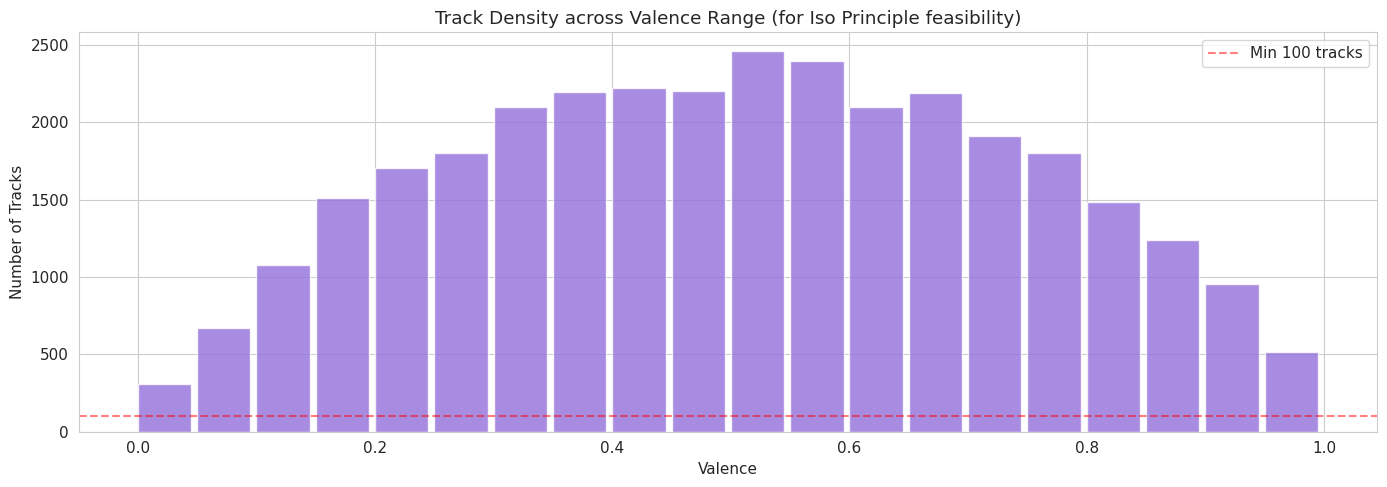

In [5]:
def simulate_iso_playlist(df, current_valence, target_valence, steps=5, tolerance=0.05):
    """동질 원리 플레이리스트 경로에 충분한 곡이 있는지 시뮬레이션"""
    valence_targets = np.linspace(current_valence, target_valence, steps)
    
    print(f"=== Iso Principle: valence {current_valence:.2f} → {target_valence:.2f} ({steps} steps) ===")
    print(f"    Tolerance: ±{tolerance}")
    
    results = []
    for i, target_v in enumerate(valence_targets):
        nearby = df[(df['valence'] >= target_v - tolerance) & (df['valence'] <= target_v + tolerance)]
        results.append({
            'Step': i + 1,
            'Target Valence': f'{target_v:.3f}',
            'Available Tracks': len(nearby),
            'Genres': nearby['playlist_genre'].nunique()
        })
        print(f"  Step {i+1}: target_v={target_v:.3f} → {len(nearby):,}곡 available ({nearby['playlist_genre'].nunique()} genres)")
    
    return pd.DataFrame(results)

# 시나리오 1: 우울 → 편안 (상승)
print("▶ Scenario 1: Depression → Calm\n")
iso1 = simulate_iso_playlist(df, 0.15, 0.50, steps=5)

print("\n" + "="*60)
print("\n▶ Scenario 2: Anxious → Peaceful\n")
iso2 = simulate_iso_playlist(df, 0.25, 0.60, steps=5)

print("\n" + "="*60)
print("\n▶ Scenario 3: Excited → Calm (하강)\n")
iso3 = simulate_iso_playlist(df, 0.85, 0.50, steps=5)

# valence 구간별 곡 수 분포
print("\n\n=== Valence 구간별 곡 수 (0.05 간격) ===")
valence_bins = np.arange(0, 1.05, 0.05)
valence_hist, _ = np.histogram(df['valence'], bins=valence_bins)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(valence_bins[:-1], valence_hist, width=0.045, color='mediumpurple', edgecolor='white', alpha=0.8, align='edge')
ax.set_xlabel('Valence')
ax.set_ylabel('Number of Tracks')
ax.set_title('Track Density across Valence Range (for Iso Principle feasibility)')
ax.axhline(100, color='red', linestyle='--', alpha=0.5, label='Min 100 tracks')
ax.legend()
plt.tight_layout()
plt.show()

## 5.5 데이터셋 한계 정량화

In [6]:
# 각 추천 시나리오별 잠재적 한계 정리
print("=" * 70)
print("  MindTune 데이터셋 한계 정량 분석")
print("=" * 70)

# 1. 집중/수면 음악 (instrumentalness 높은 곡)
instrumental = (df['instrumentalness'] >= 0.5).sum()
print(f"\n1. 기악곡 (instrumentalness ≥ 0.5): {instrumental}곡 ({instrumental/len(df)*100:.1f}%)")
print(f"   → 코딩/집중/수면 추천 시 후보 제한적일 수 있음")

# 2. 어쿠스틱 곡
acoustic = (df['acousticness'] >= 0.5).sum()
print(f"\n2. 어쿠스틱 곡 (acousticness ≥ 0.5): {acoustic}곡 ({acoustic/len(df)*100:.1f}%)")

# 3. 저에너지 차분한 곡
calm = ((df['energy'] <= 0.3) & (df['valence'] <= 0.3)).sum()
print(f"\n3. 매우 차분한 곡 (energy ≤ 0.3, valence ≤ 0.3): {calm}곡 ({calm/len(df)*100:.1f}%)")
print(f"   → 극도의 우울/이완 시 추천 후보 제한적")

# 4. Mental Health 소수 라벨
for label in ['Depression', 'PTSD', 'Dementia', 'OCD']:
    if label in df['Mental_Health_Label'].values:
        count = (df['Mental_Health_Label'] == label).sum()
        print(f"\n4. {label} 라벨: {count}곡 → 라벨 기반 직접 추천 시 반복 불가피")

# 5. 한국 곡 부재
korean_artists = df[df['track_artist'].str.contains('BTS|BLACKPINK|IU|아이유', case=False, na=False)]
print(f"\n5. K-pop 아티스트 존재 여부: {len(korean_artists)}곡")
print(f"   → 한국어 사용자 대상 서비스에서 친숙한 곡 부재 가능성")

print(f"\n{'=' * 70}")
print(f"  총 곡 수: {len(df):,}곡 — 대부분의 추천 시나리오에 충분하나,")
print(f"  특수 조건(기악곡, 극저에너지, 소수 MH 라벨)에서 다양성 제한")
print(f"{'=' * 70}")

  MindTune 데이터셋 한계 정량 분석

1. 기악곡 (instrumentalness ≥ 0.5): 2752곡 (8.4%)
   → 코딩/집중/수면 추천 시 후보 제한적일 수 있음

2. 어쿠스틱 곡 (acousticness ≥ 0.5): 3465곡 (10.6%)

3. 매우 차분한 곡 (energy ≤ 0.3, valence ≤ 0.3): 423곡 (1.3%)
   → 극도의 우울/이완 시 추천 후보 제한적

4. Depression 라벨: 138곡 → 라벨 기반 직접 추천 시 반복 불가피

4. PTSD 라벨: 38곡 → 라벨 기반 직접 추천 시 반복 불가피

4. Dementia 라벨: 8곡 → 라벨 기반 직접 추천 시 반복 불가피

4. OCD 라벨: 8곡 → 라벨 기반 직접 추천 시 반복 불가피

5. K-pop 아티스트 존재 여부: 77곡
   → 한국어 사용자 대상 서비스에서 친숙한 곡 부재 가능성

  총 곡 수: 32,833곡 — 대부분의 추천 시나리오에 충분하나,
  특수 조건(기악곡, 극저에너지, 소수 MH 라벨)에서 다양성 제한


## 5.6 종합 결론

### EDA에서 발견한 핵심 인사이트

**1. 데이터 품질**: 결측값 극소수(5건), 중복 존재 가능 → 전처리 시 dedup 필수

**2. 감정 공간**: valence × energy 2D 공간에서 사분면별 곡 수 확인 → 대부분 시나리오에서 충분한 후보곡 확보

**3. Mental Health Label**:
- 극심한 불균형 (Normal 67.5%, PTSD 0.1%)
- 라벨 간 피처 차이가 통계적으로 유의 → 라벨 기반 추천의 근거 존재
- 소수 라벨은 피처 기반 필터링으로 보완 필요

**4. 장르**: 6개 장르 균등 분포 → 다양한 추천 가능. 장르 간 피처 유사도가 cross-genre 추천 가능성을 시사

**5. 추천 시스템 설계 시사점**:
- 감정/상황 프리셋 범위에 매칭되는 곡 수를 사전 검증하여 빈약한 영역 파악
- 동질 원리 플레이리스트는 valence 전 구간에서 충분한 곡 밀도 필요
- 기악곡/어쿠스틱 곡이 상대적으로 적어 집중/수면 추천 시 주의
- 하이브리드 검색(벡터 + 피처)이 특히 피처 빈약 영역에서 중요

### 기획안 보완 포인트
- 감정-피처 매핑 가이드의 범위를 EDA 결과에 맞게 미세 조정
- 매칭 곡이 부족한 상황 프리셋의 조건 완화 전략 명시
- 소수 Mental Health Label에 대한 fallback 전략 구체화